<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
data = load_iris()
samples = [10, 25, 50]
data.target[samples]
data.target_names[data.target[samples]]

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)
print(X_train)
print(X_test)

[[5.1 2.5 3.  1.1]
 [6.2 2.2 4.5 1.5]
 [5.1 3.8 1.5 0.3]
 [6.8 3.2 5.9 2.3]
 [5.7 2.8 4.1 1.3]
 [6.7 3.  5.2 2.3]
 [4.9 3.1 1.5 0.1]
 [5.1 3.8 1.6 0.2]
 [4.4 2.9 1.4 0.2]
 [7.1 3.  5.9 2.1]
 [6.5 3.2 5.1 2. ]
 [4.9 3.  1.4 0.2]
 [5.  3.  1.6 0.2]
 [6.  2.9 4.5 1.5]
 [5.5 2.4 3.8 1.1]
 [7.2 3.2 6.  1.8]
 [5.  3.4 1.6 0.4]
 [4.7 3.2 1.6 0.2]
 [6.7 3.3 5.7 2.5]
 [5.9 3.2 4.8 1.8]
 [5.4 3.4 1.5 0.4]
 [6.3 2.7 4.9 1.8]
 [7.6 3.  6.6 2.1]
 [7.7 2.8 6.7 2. ]
 [5.7 3.  4.2 1.2]
 [4.6 3.4 1.4 0.3]
 [5.1 3.7 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [6.9 3.1 4.9 1.5]
 [5.5 2.5 4.  1.3]
 [5.7 4.4 1.5 0.4]
 [5.1 3.5 1.4 0.3]
 [5.8 2.7 4.1 1. ]
 [5.6 2.9 3.6 1.3]
 [4.8 3.  1.4 0.1]
 [4.8 3.  1.4 0.3]
 [6.7 3.1 4.4 1.4]
 [6.3 2.5 5.  1.9]
 [7.9 3.8 6.4 2. ]
 [5.1 3.5 1.4 0.2]
 [6.4 2.8 5.6 2.1]
 [4.6 3.2 1.4 0.2]
 [6.  2.2 5.  1.5]
 [5.5 3.5 1.3 0.2]
 [6.3 3.3 6.  2.5]
 [6.  2.2 4.  1. ]
 [4.8 3.4 1.9 0.2]
 [7.7 3.  6.1 2.3]
 [6.1 2.8 4.  1.3]
 [5.7 2.5 5.  2. ]
 [5.8 2.7 3.9 1.2]
 [4.5 2.3 1.3 0.3]
 [5.5 2.4 3.

# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print("Acurácia no treino:", acc_train)
print("Acurácia no teste:", acc_test)

Acurácia no treino: 1.0
Acurácia no teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

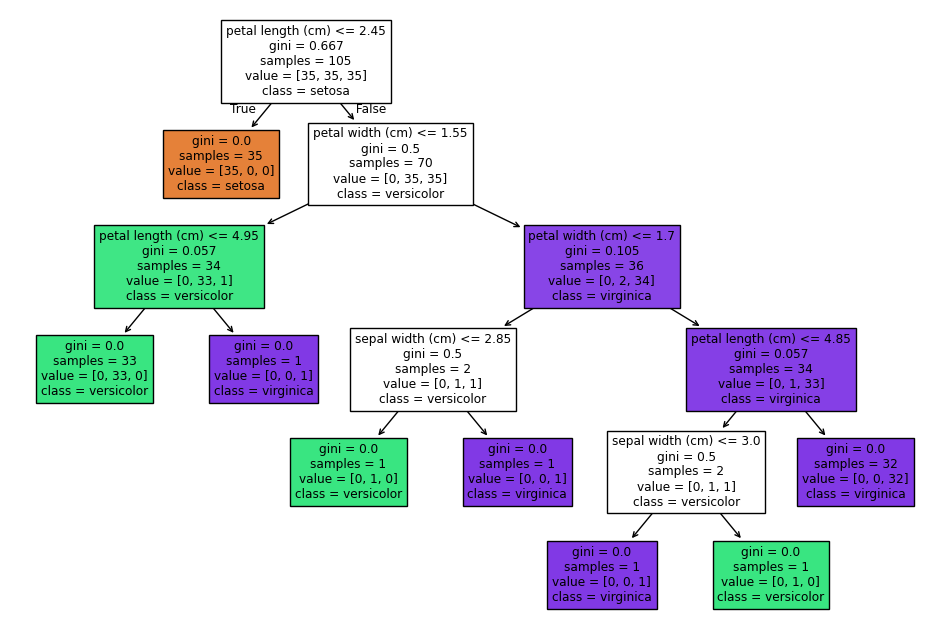

In [3]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.show()

**Adicione seu texto de solução aqui**.


Questão 1 : Petal lenght(cm) <= 2.45 Questão 2 : 5

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [4]:
import pandas as pd

results = []

depths = [1,2,3,4,5,6,7,8,9,None]

for d in depths:

    model = DecisionTreeClassifier(max_depth=d, random_state=42)

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    depth_real = model.get_depth()
    leaves = model.get_n_leaves()

    results.append([d, acc_train, acc_test, depth_real, leaves])

df = pd.DataFrame(
    results,
    columns=[
        "max_depth",
        "acuracia_treino",
        "acuracia_teste",
        "profundidade_real",
        "num_folhas"
    ]
)

print(df)

   max_depth  acuracia_treino  acuracia_teste  profundidade_real  num_folhas
0        1.0         0.666667        0.666667                  1           2
1        2.0         0.971429        0.888889                  2           3
2        3.0         0.980952        0.977778                  3           5
3        4.0         0.990476        0.888889                  4           7
4        5.0         1.000000        0.933333                  5           8
5        6.0         1.000000        0.933333                  5           8
6        7.0         1.000000        0.933333                  5           8
7        8.0         1.000000        0.933333                  5           8
8        9.0         1.000000        0.933333                  5           8
9        NaN         1.000000        0.933333                  5           8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O Overfiting começa na sexta interação.
A arvore consegue 100% quando a max_depth=none porque ele irá dividir tão especificamente cada classificação que ele irá dividir quantas vezes for necessario para deixar todos nós puros

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [5]:
criterios = ["gini", "entropy"]

resultados = []
for i in range(10):
    for c in criterios:

        model = DecisionTreeClassifier(
            criterion=c,
            random_state=42
        )

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        acc_train = accuracy_score(y_train, y_train_pred)
        acc_test = accuracy_score(y_test, y_test_pred)

        profundidade = model.get_depth()
        folhas = model.get_n_leaves()

        resultados.append([c, acc_train, acc_test, profundidade, folhas])

    df = pd.DataFrame(
        resultados,
        columns=[
            "criterio",
            "acuracia_treino",
            "acuracia_teste",
            "profundidade",
            "num_folhas"
        ]
    )

print(df)
    

   criterio  acuracia_treino  acuracia_teste  profundidade  num_folhas
0      gini              1.0        0.933333             5           8
1   entropy              1.0        0.888889             6           8
2      gini              1.0        0.933333             5           8
3   entropy              1.0        0.888889             6           8
4      gini              1.0        0.933333             5           8
5   entropy              1.0        0.888889             6           8
6      gini              1.0        0.933333             5           8
7   entropy              1.0        0.888889             6           8
8      gini              1.0        0.933333             5           8
9   entropy              1.0        0.888889             6           8
10     gini              1.0        0.933333             5           8
11  entropy              1.0        0.888889             6           8
12     gini              1.0        0.933333             5           8
13  en

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [6]:
splits = [2,4,6,8,10,15,20,30,50,100]

resultados = []

for s in splits:

    model = DecisionTreeClassifier(
        min_samples_split=s,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    profundidade = model.get_depth()
    folhas = model.get_n_leaves()

    resultados.append([s, acc_train, acc_test, profundidade, folhas])

df = pd.DataFrame(
    resultados,
    columns=[
        "min_samples_split",
        "acuracia_treino",
        "acuracia_teste",
        "profundidade",
        "num_folhas"
    ]
)

print(df)

   min_samples_split  acuracia_treino  acuracia_teste  profundidade  \
0                  2         1.000000        0.933333             5   
1                  4         0.980952        0.933333             4   
2                  6         0.980952        0.933333             4   
3                  8         0.980952        0.933333             4   
4                 10         0.980952        0.933333             4   
5                 15         0.980952        0.933333             4   
6                 20         0.980952        0.933333             4   
7                 30         0.980952        0.933333             4   
8                 50         0.971429        0.888889             2   
9                100         0.666667        0.666667             1   

   num_folhas  
0           8  
1           6  
2           6  
3           6  
4           6  
5           6  
6           6  
7           6  
8           3  
9           2  
